# Environment Preparation


In [4]:
!pip install trimesh

In [5]:
#Template for this notebook as well as datasets were provided by Martin Madaras and Skeletex s.r.o.. We used this as core and expanded with our
#own experiments using DLG algorithm.

import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"

import time
import random
import tensorflow as tf
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objs as go
import trimesh


In [6]:
from google.colab import drive
drive.mount('/content/gdrive')
root_path = 'gdrive/My Drive/Colab Notebooks/'

MOTION_CAM_MAX_RANGE = 1800
DATASET_THRUSTER = root_path + '/Skeletex3DData/thruster/'
DATASET_ARMADILLO = root_path + '/Skeletex3DData/armadillo/'
DATASET = DATASET_ARMADILLO

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Data Exploration

In [7]:
def load_scan(positions_path, normals_path, load_xyz=False):
  positions = cv2.imread(positions_path,  cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
  print(positions_path)
  positions = cv2.resize(positions, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
  normals = cv2.imread(normals_path,  cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
  normals = cv2.resize((normals + 1) / 2, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
  xyz = []
  if load_xyz:
    for y in range(positions.shape[0]):
      for x in range(positions.shape[1]):
        if not np.all(positions[y][x] == 0) and random.randrange(20) == 0:
          xyz.append(positions[y][x])
  xyz = np.array(xyz)
  return positions, normals, xyz

In [8]:
p_path = DATASET + 'train/scan_000_positions.exr'
n_path = DATASET + 'train/scan_000_normals.exr'
positions, normals, xyz = load_scan(p_path, n_path, True)
print(positions.shape)
print(normals.shape)
print(xyz.shape)

gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_000_positions.exr
(772, 1032, 3)
(772, 1032, 3)
(25703, 3)


In [9]:
def load_mask(labels_path):
  mask = cv2.imread(labels_path,  cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
  mask = cv2.resize(mask, (0,0), fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
  mask = mask[:,:,2]
  mask = np.expand_dims(mask, axis =2)
  mask = (mask>1).astype(float)
  return mask

In [10]:
mask = load_mask(DATASET + '/train/scan_000_labels.png')
print(np.amax(mask))
print(mask.shape)

1.0
(772, 1032, 1)


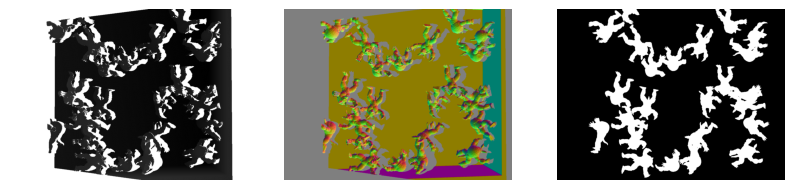

In [11]:
def show(depth, normals, mask):
  plt.figure(figsize=(10, 7))

  plt.subplot(1, 3, 1)
  plt.axis('off')
  plt.imshow(-depth).set_cmap('gray')

  plt.subplot(1, 3, 2)
  plt.axis('off')
  plt.imshow(normals)

  plt.subplot(1, 3, 3)
  plt.axis('off')
  plt.imshow(mask[:, :, 0]).set_cmap('gray')

  plt.show()

show(positions[:, :, 2], normals, mask)

def show_pred(depth, normals, mask):
  plt.figure(figsize=(26, 20))

  plt.subplot(1, 3, 1)
  plt.axis('off')
  plt.imshow(-depth).set_cmap('gray')

  plt.subplot(1, 3, 2)
  plt.axis('off')
  plt.imshow(normals)

  plt.subplot(1, 3, 3)
  plt.axis('off')
  plt.imshow(mask).set_cmap('gray')

  plt.show()


# Dataset Parser

In [12]:
class Generator(tf.keras.utils.Sequence):
    def __init__(self, datasets_path, gt=True):
        self.inputs, self.masks, self.positions, self.xyzs = [], [], [], []
        self.gt = gt
        self.load_data(datasets_path)

    def load_data(self, dataset_path):
        files = os.listdir(dataset_path)
        random.shuffle(files)
        for f in files:
            if "_positions" in f:
                print(dataset_path + f[:-13])
                p_path = dataset_path + f
                n_path = dataset_path + f[:-13] + 'normals.exr'
                positions, normals, xyz = load_scan(p_path, n_path, not self.gt)
                depth = positions[:, :, 2] / MOTION_CAM_MAX_RANGE
                depth = np.expand_dims(depth, axis=2)
                stacked = np.concatenate([normals, depth], axis=2)
                self.inputs.append(np.expand_dims(stacked, axis=0))
                if self.gt:
                  mask = load_mask(dataset_path + f[:-13] + 'labels.png')
                  self.masks.append(np.expand_dims(mask, axis = 0))
                else:
                  self.positions.append(positions)
                  self.xyzs.append(xyz)

    def get_positions_and_xyzs(self, index):
        return self.positions[index], self.xyzs[index]

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return self.inputs[index], self.masks[index] if self.gt else None

In [14]:
train_generator = Generator(DATASET + 'train/')
#val_generator = Generator(DATASET + 'val/')
#test_generator = Generator(DATASET + 'test/')
real_generator = Generator(DATASET + 'real/', gt=False)

gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_018_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_018_positions.exr
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_093_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_093_positions.exr
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_020_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_020_positions.exr
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_042_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_042_positions.exr
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_051_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_051_positions.exr
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_044_
gdrive/My Drive/Colab Notebooks//Skeletex3DData/armadillo/train/scan_044_positions.exr
gdrive/My Drive/Colab Notebooks//S

In [18]:
test_input, test_mask = train_generator[1]
print(test_input.shape)
print(test_mask.shape)

(1, 772, 1032, 4)
(1, 772, 1032, 1)


# Neural Network


In [19]:
def net(i):
    c1 = tf.keras.layers.Conv2D(16,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(i)
    c1 = tf.keras.layers.Conv2D(16,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D(2)(c1)

    c2 = tf.keras.layers.Conv2D(24,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(24,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D(2)(c2)

    c3 = tf.keras.layers.Conv2D(48,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(48,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(c3)


    u4 = tf.keras.layers.Conv2DTranspose(24,2, strides = (2,2), padding='same')(c3)
    u4 = tf.keras.layers.concatenate([u4,c2])

    c4 = tf.keras.layers.Conv2D(24,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(u4)
    c4 = tf.keras.layers.Conv2D(24,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(c4)

    u5 = tf.keras.layers.Conv2DTranspose(16,2, strides = (2,2), padding='same')(c4)
    u5 = tf.keras.layers.concatenate([u5,c1])

    c5 = tf.keras.layers.Conv2D(16,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(u5)
    c5 = tf.keras.layers.Conv2D(16,3,activation=tf.keras.layers.LeakyReLU(), padding='same')(c5)



    o = tf.keras.layers.Conv2D(1, 1, activation='sigmoid') (c5)
    return o


def generate():
    i = tf.keras.Input(shape=(None, None, 4))
    o = net(i)
    model = tf.keras.Model(inputs=i, outputs=o)

    print(model.summary())
    print('Total number of layers: {}'.format(len(model.layers)))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

    return model

model = generate()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 4)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        592 │ input_layer[0][0] │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      2,320 │ conv2d[0][0]      │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      3,480 │ max_pooling2d[0]… │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,208 │ conv2d_2[0][0]    │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     10,416 │ max_pooling2d_1[… │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     20,784 │ conv2d_4[0][0]    │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, None,      │      4,632 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 48)         │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │     10,392 │ concatenate[0][0] │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │      5,208 │ conv2d_6[0][0]    │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, None,      │      1,552 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 32)         │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │      4,624 │ concatenate_1[0]… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │      2,320 │ conv2d_8[0][0]  

 Total params: 71,545 (279.47 KB)

 Trainable params: 71,545 (279.47 KB)

 Non-trainable params: 0 (0.00 B)

None
Total number of layers: 18


In [20]:
start = time.time()
#history = model.fit(train_generator,
#                    epochs=32,
#                    validation_data=val_generator,
#                    validation_freq=5)
print(f"Elapsed time: {time.time() - start} seconds")

Elapsed time: 9.322166442871094e-05 seconds


(1, 772, 1032, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
(1, 772, 1032, 1)


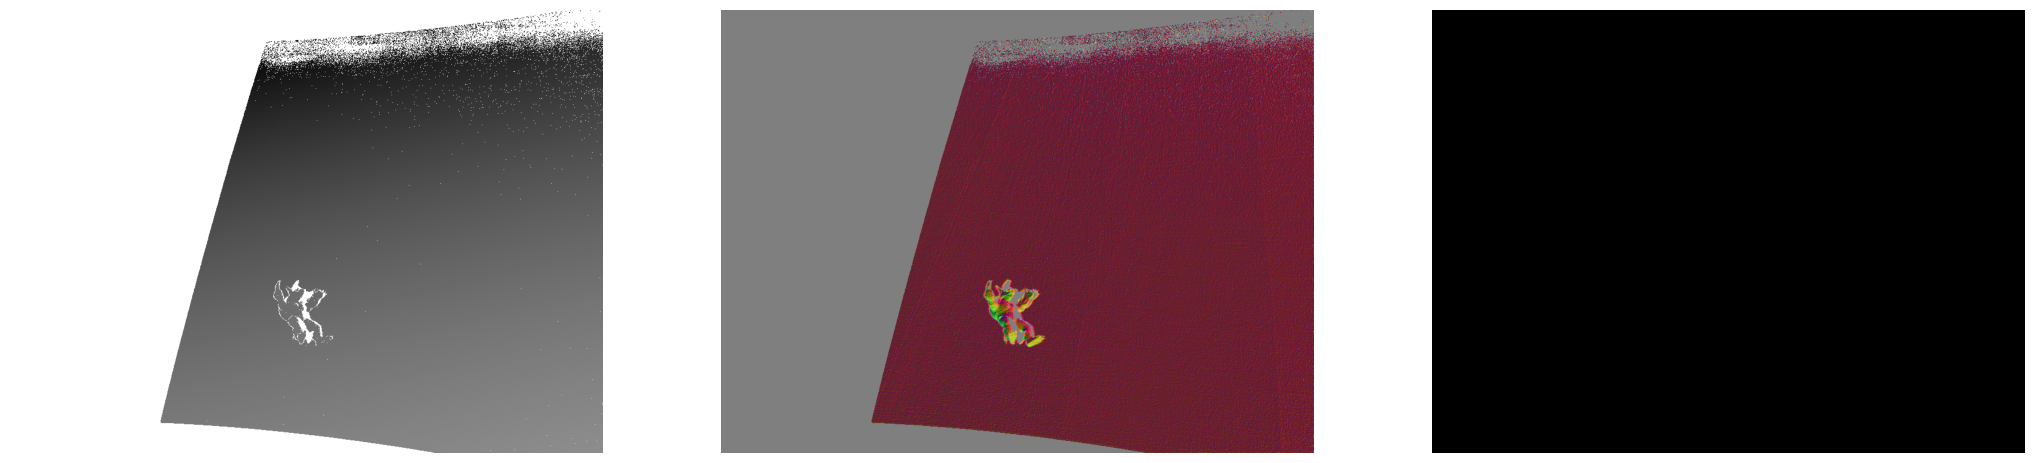

In [22]:
real_input, _ = real_generator[2]
print(real_input.shape)
prediction = model.predict(real_input)
print(prediction.shape)
show_pred(real_input[0, :, :, 3], real_input[0,:,:,:3], prediction[0] > 0.97)
#model.save_weights("model.weights.h5")

<h1>DLG EXPERIMENTS</h1>

In [23]:
def total_variation(x):
    """
    Compute anisotropic Total Variation (TV) regularization for a batch of images.

    Total Variation measures the sum of absolute differences between neighboring
    pixels in the horizontal and vertical directions, encouraging spatial
    smoothness while preserving sharp edges. In the context of gradient inversion
    attacks, TV acts as a generic image-domain prior that suppresses high-frequency
    noise and discourages implausible reconstructions.

    This regularizer is widely used in state-of-the-art gradient reconstruction
    methods, including:
      - "Inverting Gradients – How easy is it to break privacy in federated learning?"
        (Geiping et al., NeurIPS 2020)
      - "See through Gradients: Image Batch Recovery via GradInversion"
        (Yin et al., CVPR 2021)

    In our setting, TV regularization is modality-agnostic and particularly suitable
    for 3D-derived inputs such as depth maps and surface normal maps, which are
    expected to exhibit piecewise smooth spatial structure. The TV term narrows
    the solution space of the ill-posed gradient inversion problem by favoring
    smooth, physically plausible reconstructions without injecting task- or
    label-specific information.

    Args:
        x (tf.Tensor): Reconstructed input tensor of shape (B, H, W, C),
                       where B is batch size, H and W are spatial dimensions,
                       and C is the number of channels.

    Returns:
        tf.Tensor: Scalar total variation penalty summed over batch, spatial
                   dimensions, and channels.
    """
    tv_h = tf.reduce_sum(tf.abs(x[:, 1:, :, :] - x[:, :-1, :, :]))
    tv_w = tf.reduce_sum(tf.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    return tv_h + tv_w


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 4)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, None,      │        592 │ input_layer_2[0]… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, None,      │      2,320 │ conv2d_22[0][0]   │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, None,      │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, None,      │      3,480 │ max_pooling2d_4[… │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, None,      │      5,208 │ conv2d_24[0][0]   │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, None,      │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, None,      │     10,416 │ max_pooling2d_5[… │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, None,      │     20,784 │ conv2d_26[0][0]   │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, None,      │      4,632 │ conv2d_27[0][0]   │
│ (Conv2DTranspose)   │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 48)         │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, None,      │     10,392 │ concatenate_4[0]… │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, None,      │      5,208 │ conv2d_28[0][0]   │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, None,      │      1,552 │ conv2d_29[0][0]   │
│ (Conv2DTranspose)   │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 32)         │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, None,      │      4,624 │ concatenate_5[0]… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, None,      │      2,320 │ conv2d_30[0][0] 

 Total params: 71,545 (279.47 KB)

 Trainable params: 71,545 (279.47 KB)

 Non-trainable params: 0 (0.00 B)

None
Total number of layers: 18


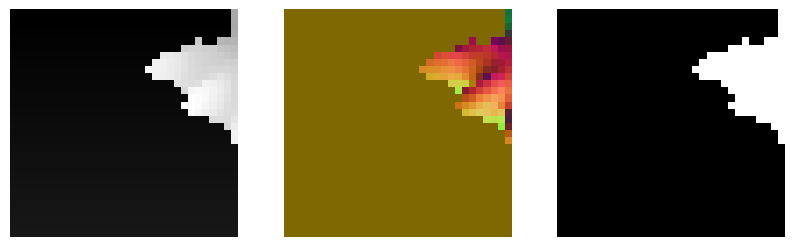

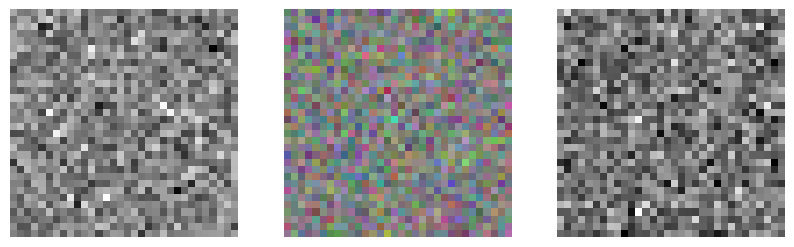

Layer 0, Iter 0, Loss 0.5258


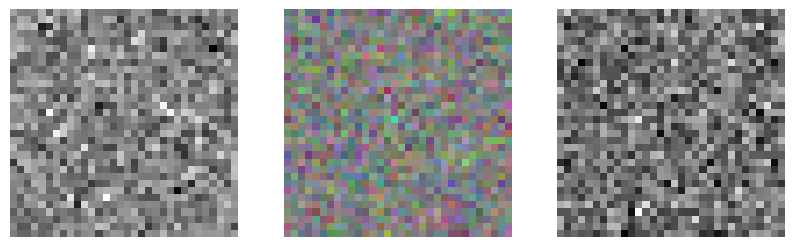

Layer 0, Iter 600, Loss 0.0039


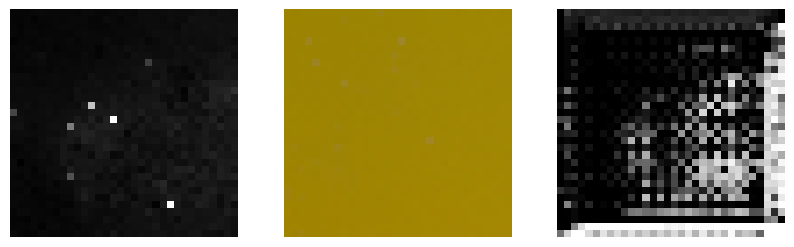

KeyboardInterrupt: 

In [ ]:
# --- DLG experiments (revised) ---
import tensorflow_probability as tfp
from scipy.optimize import minimize

model = generate()
initial_weights = model.get_weights()

index = np.random.randint(0, len(train_generator), 1)[0]
sample, label = train_generator[index]
sample = sample[:, 300:332, 300:332, :]
label  = label[:, 300:332, 300:332, :]

normal = sample[0][..., :3]
depth  = sample[0][..., 3]
show(depth, normal, label[0])

loss_fn = tf.keras.losses.BinaryCrossentropy()

# Compute original gradients
with tf.GradientTape() as tape:
    y = model(sample, training=False)
    loss = loss_fn(label, y)

orig_grad = tape.gradient(loss, model.trainable_variables)

# Dummy variables
dummy_sample = tf.Variable(
    np.random.normal(0.5, 0.1, size=sample.shape),
    dtype=tf.float32
)

dummy_label = tf.Variable(
    np.random.normal(0.5, 0.1, size=label.shape),
    dtype=tf.float32
)

show(dummy_sample[0][..., 3], dummy_sample[0][..., :3], dummy_label[0])

# Limit number of layers used for matching
max_layers = min(15, len(orig_grad))

for i in range(max_layers):
    lr = 0.015 - 0.001 * i
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for iters in range(1201):
        with tf.GradientTape(persistent=True) as tape:
            dummy_pred = model(dummy_sample, training=False)
            dummy_loss = loss_fn(dummy_label, dummy_pred)

            dummy_grad = tape.gradient(
                dummy_loss, model.trainable_variables
            )

            grad_diff = tf.add_n([
                tf.reduce_sum((max_layers - j) * tf.square(dg - og))
                for j, (dg, og) in enumerate(
                    zip(dummy_grad[:i+1], orig_grad[:i+1])
                )
            ])

            #cosine similiarity diff
            #grad_diff = tf.add_n([
            #    tf.reduce_sum(
            #        1 - tf.nn.l2_normalize(gx) * tf.nn.l2_normalize(gy)
            #    ) for gx, gy in zip(dummy_grad, orig_grad)
            #])

            # box constraint penalty
            penalty = tf.reduce_sum(
                tf.square(dummy_sample - tf.clip_by_value(dummy_sample, 0.0, 1.0))
            )

            # --- TV regularization (SOTA addition) ---
            tv_weight = 1e-4   # safe starting value
            tv_penalty = total_variation(dummy_sample)

            # Final objective
            #total_loss = grad_diff + 2.0 * penalty # before visapp reviews
            total_loss = grad_diff + 2.0 * penalty + tv_weight * tv_penalty

        grads = tape.gradient(total_loss, [dummy_sample, dummy_label])
        del tape

        optimizer.apply_gradients(zip(grads, [dummy_sample, dummy_label]))
        dummy_label.assign(tf.clip_by_value(dummy_label, 0.0, 1.0))

        if iters % 600 == 0:
            print(f"Layer {i}, Iter {iters}, Loss {total_loss.numpy():.4f}")
            show(
                dummy_sample[0][..., 3],
                dummy_sample[0][..., :3],
                dummy_label[0]
            )

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 4)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, None,      │        592 │ input_layer_3[0]… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, None,      │      2,320 │ conv2d_33[0][0]   │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, None,      │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, None,      │      3,480 │ max_pooling2d_6[… │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, None,      │      5,208 │ conv2d_35[0][0]   │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, None,      │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, None,      │     10,416 │ max_pooling2d_7[… │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, None,      │     20,784 │ conv2d_37[0][0]   │
│                     │ None, 48)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, None,      │      4,632 │ conv2d_38[0][0]   │
│ (Conv2DTranspose)   │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 48)         │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, None,      │     10,392 │ concatenate_6[0]… │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, None,      │      5,208 │ conv2d_39[0][0]   │
│                     │ None, 24)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, None,      │      1,552 │ conv2d_40[0][0]   │
│ (Conv2DTranspose)   │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 32)         │            │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, None,      │      4,624 │ concatenate_7[0]… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, None,      │      2,320 │ conv2d_41[0][0] 

 Total params: 71,545 (279.47 KB)

 Trainable params: 71,545 (279.47 KB)

 Non-trainable params: 0 (0.00 B)

None
Total number of layers: 18


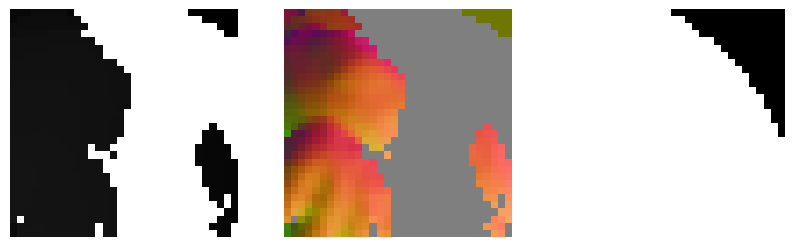

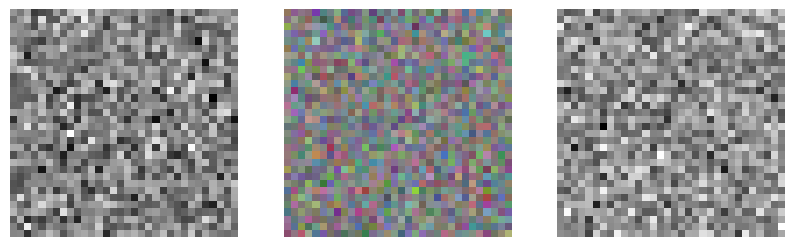

Layer 0, Iter 0, Loss 1.3642


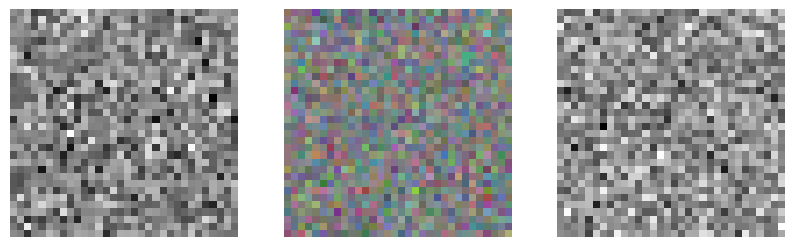

Layer 0, Iter 600, Loss 0.0470


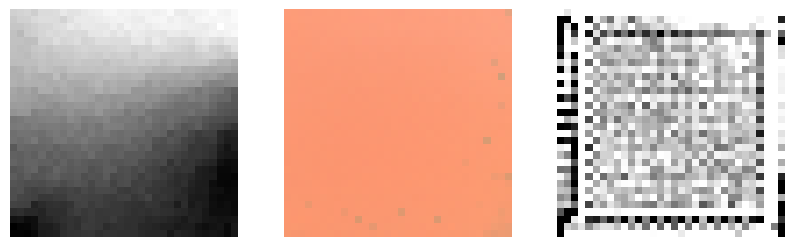

Layer 0, Iter 1200, Loss 0.0438


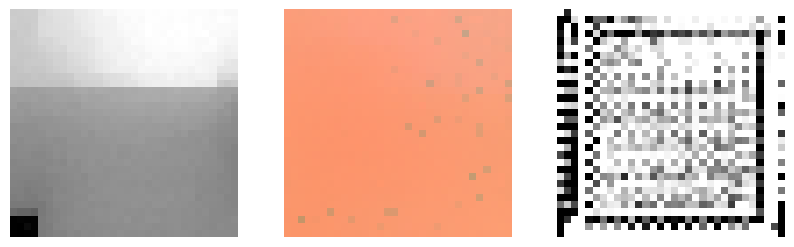

Layer 1, Iter 0, Loss 0.0612


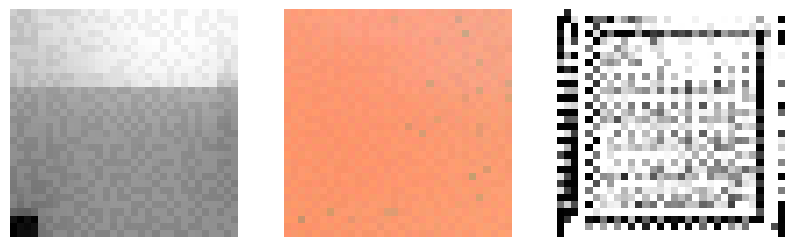

Layer 1, Iter 600, Loss 0.0108


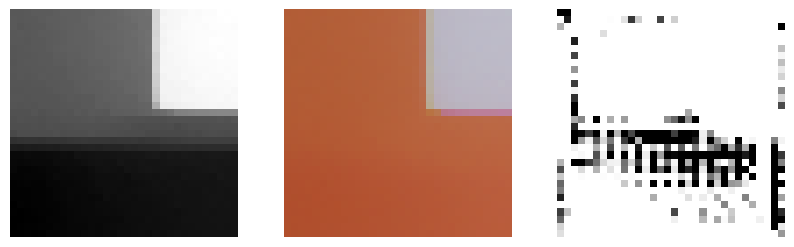

Layer 1, Iter 1200, Loss 0.0123


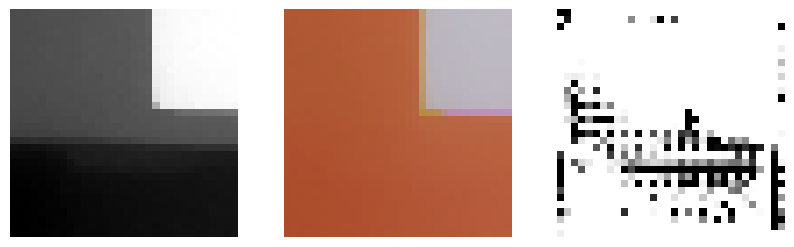

Layer 2, Iter 0, Loss 0.0210


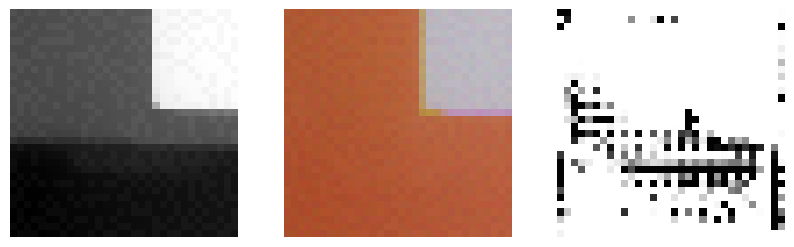

Layer 2, Iter 600, Loss 0.0164


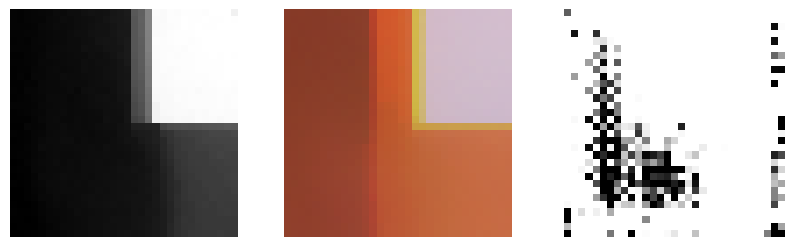

Layer 2, Iter 1200, Loss 0.0176


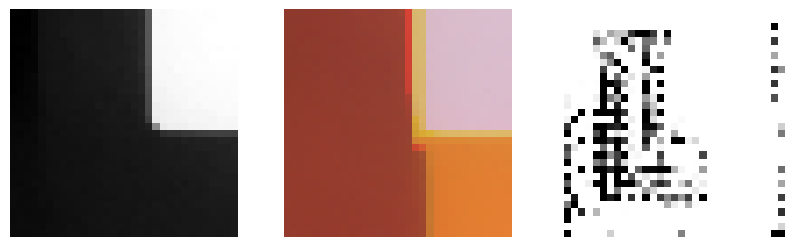

Layer 3, Iter 0, Loss 0.0202


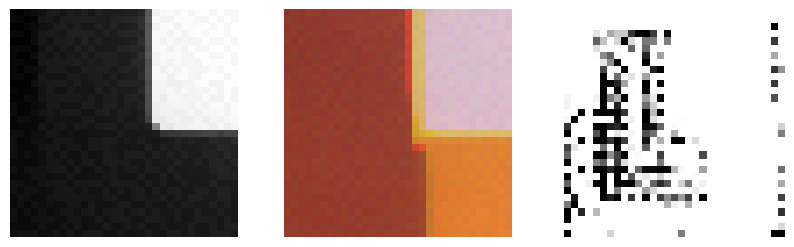

Layer 3, Iter 600, Loss 0.0197


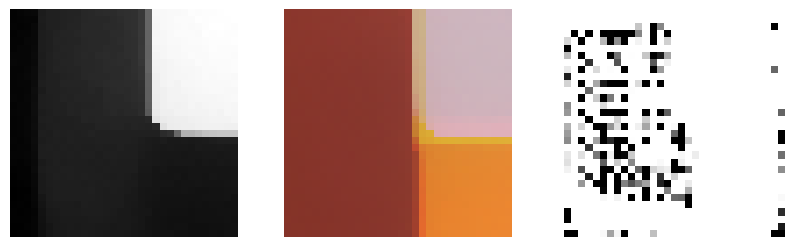

Layer 3, Iter 1200, Loss 0.0187


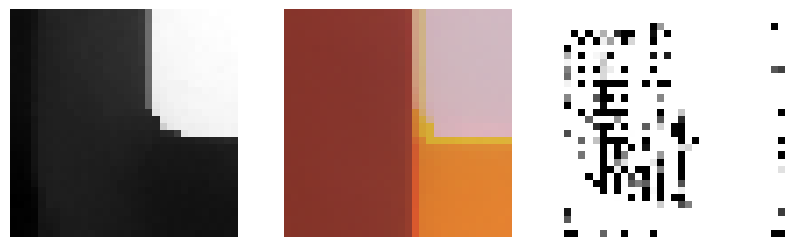

Layer 4, Iter 0, Loss 0.0189


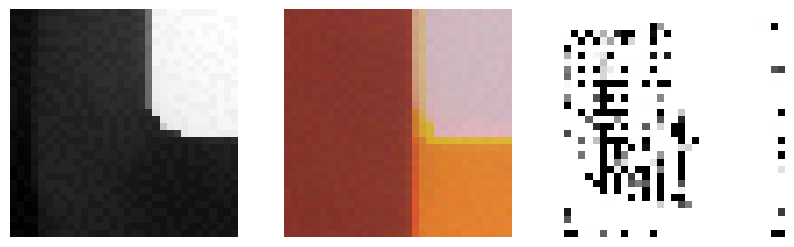

Layer 4, Iter 600, Loss 0.0192


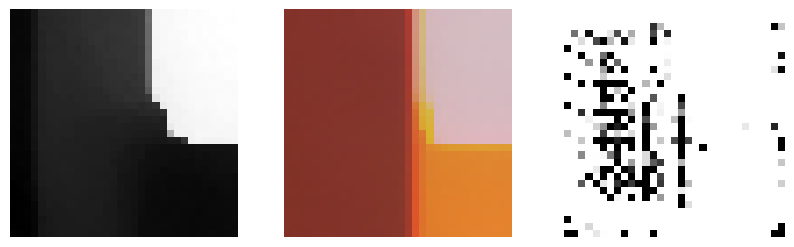

Layer 4, Iter 1200, Loss 0.0186


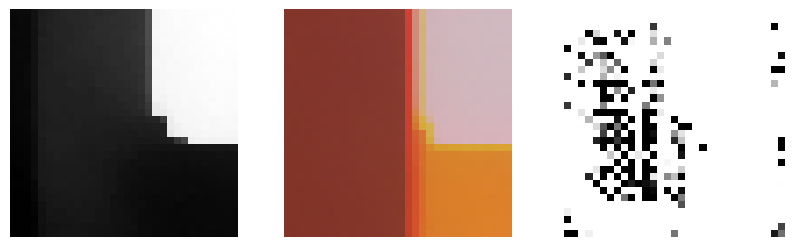

Layer 5, Iter 0, Loss 0.0186


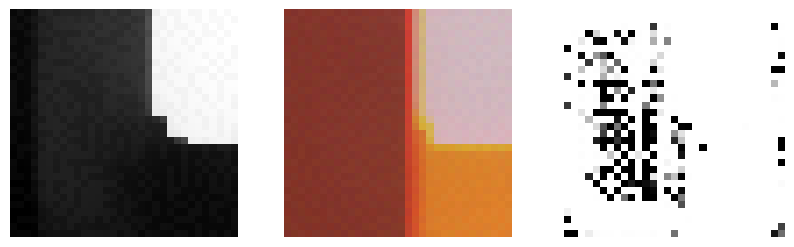

Layer 5, Iter 600, Loss 0.0175


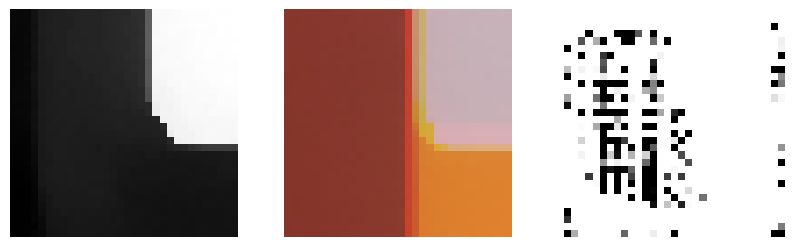

Layer 5, Iter 1200, Loss 0.0189


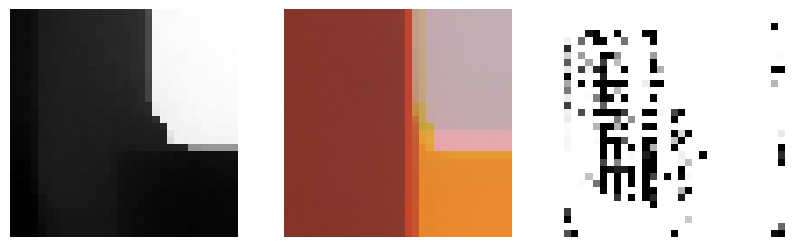

Layer 6, Iter 0, Loss 0.0189


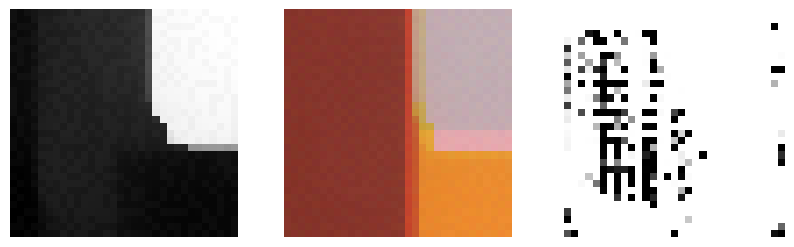

Layer 6, Iter 600, Loss 0.0189


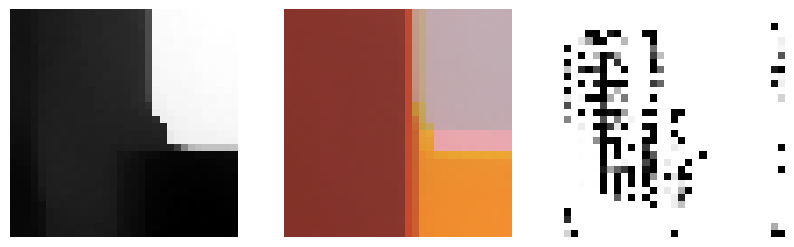

Layer 6, Iter 1200, Loss 0.0189


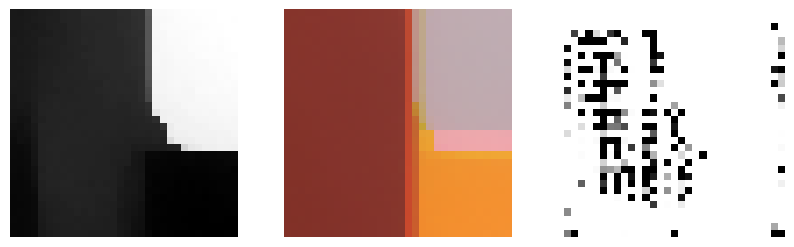

Layer 7, Iter 0, Loss 0.0189


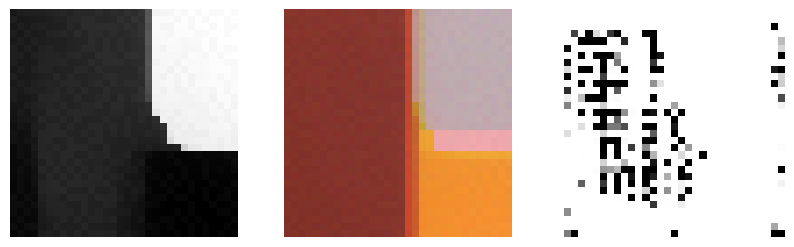

Layer 7, Iter 600, Loss 0.0195


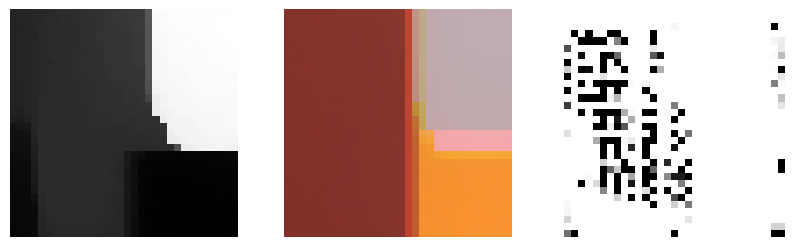

Layer 7, Iter 1200, Loss 0.0189


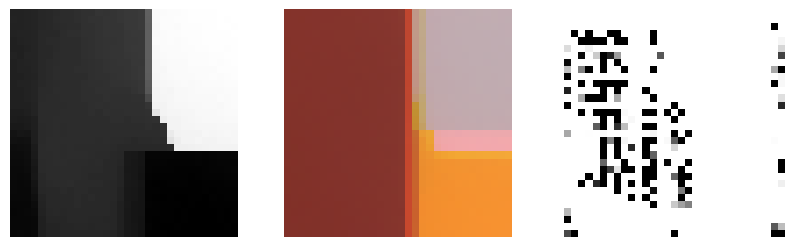

Layer 8, Iter 0, Loss 0.0190


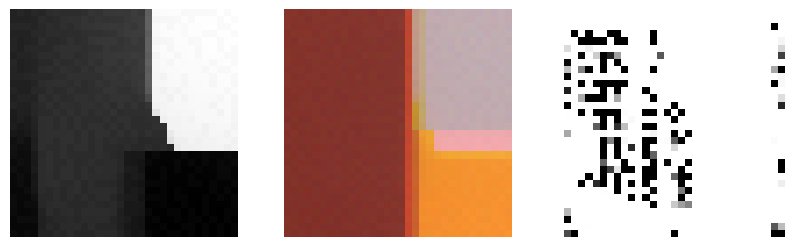

Layer 8, Iter 600, Loss 0.0190


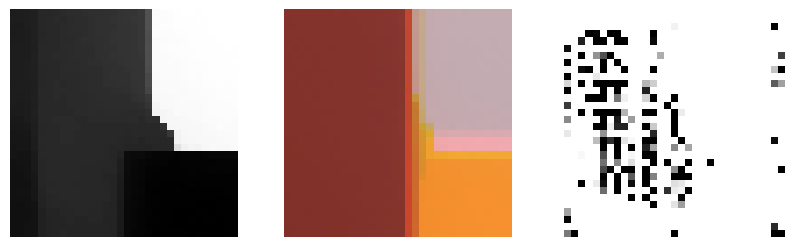

Layer 8, Iter 1200, Loss 0.0202


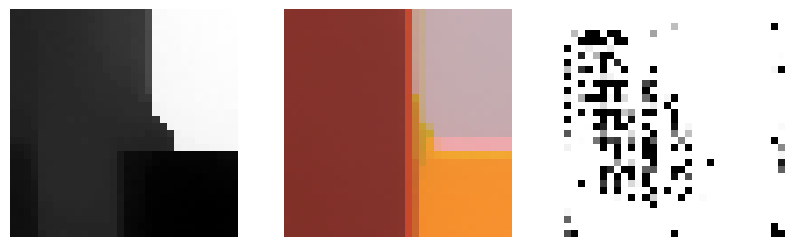

Layer 9, Iter 0, Loss 0.0203


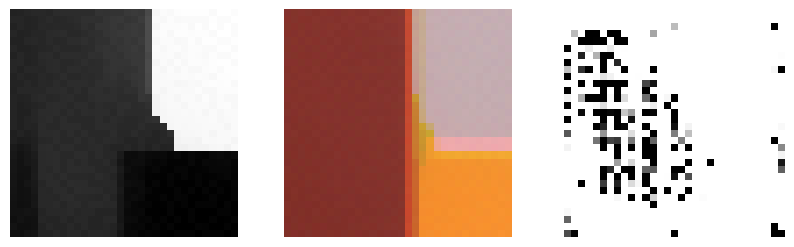

In [ ]:
# --- DLG experiments (revised) ---
import tensorflow_probability as tfp
from scipy.optimize import minimize

model = generate()
initial_weights = model.get_weights()

index = np.random.randint(0, len(train_generator), 1)[0]
sample, label = train_generator[index]
sample = sample[:, 300:332, 300:332, :]
label  = label[:, 300:332, 300:332, :]

normal = sample[0][..., :3]
depth  = sample[0][..., 3]
show(depth, normal, label[0])

loss_fn = tf.keras.losses.BinaryCrossentropy()

# Compute original gradients
with tf.GradientTape() as tape:
    y = model(sample, training=False)
    loss = loss_fn(label, y)

orig_grad = tape.gradient(loss, model.trainable_variables)

# Dummy variables
dummy_sample = tf.Variable(
    np.random.normal(0.5, 0.1, size=sample.shape),
    dtype=tf.float32
)

dummy_label = tf.Variable(
    np.random.normal(0.5, 0.1, size=label.shape),
    dtype=tf.float32
)

show(dummy_sample[0][..., 3], dummy_sample[0][..., :3], dummy_label[0])

# Limit number of layers used for matching
max_layers = min(15, len(orig_grad))

for i in range(max_layers):
    lr = 0.015 - 0.001 * i
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for iters in range(1201):
        with tf.GradientTape(persistent=True) as tape:
            dummy_pred = model(dummy_sample, training=False)
            dummy_loss = loss_fn(dummy_label, dummy_pred)

            dummy_grad = tape.gradient(
                dummy_loss, model.trainable_variables
            )

            grad_diff = tf.add_n([
                tf.reduce_sum((max_layers - j) * tf.square(dg - og))
                for j, (dg, og) in enumerate(
                    zip(dummy_grad[:i+1], orig_grad[:i+1])
                )
            ])

            #cosine similiarity diff
            #grad_diff = tf.add_n([
            #    tf.reduce_sum(
            #        1 - tf.nn.l2_normalize(gx) * tf.nn.l2_normalize(gy)
            #    ) for gx, gy in zip(dummy_grad, orig_grad)
            #])

            # box constraint penalty
            penalty = tf.reduce_sum(
                tf.square(dummy_sample - tf.clip_by_value(dummy_sample, 0.0, 1.0))
            )

            # --- TV regularization (SOTA addition) ---
            tv_weight = 1e-4   # safe starting value
            tv_penalty = total_variation(dummy_sample)

            # Final objective
            #total_loss = grad_diff + 2.0 * penalty # before visapp reviews
            total_loss = grad_diff + 2.0 * penalty + tv_weight * tv_penalty

        grads = tape.gradient(total_loss, [dummy_sample, dummy_label])
        del tape

        optimizer.apply_gradients(zip(grads, [dummy_sample, dummy_label]))
        dummy_label.assign(tf.clip_by_value(dummy_label, 0.0, 1.0))

        if iters % 600 == 0:
            print(f"Layer {i}, Iter {iters}, Loss {total_loss.numpy():.4f}")
            show(
                dummy_sample[0][..., 3],
                dummy_sample[0][..., :3],
                dummy_label[0]
            )